# Informe de Funciones de Activación Avanzadas

Este cuaderno contiene la explicación teórica y el código ejecutable interactivo de funciones de activación utilizadas en redes neuronales profundas y arquitecturas avanzadas (Transformers, CNNs modernas y Edge AI).

## 1. Tangente Hiperbólica (Tanh)

### Cómo funciona
Escala y traslada los valores de entrada al rango acotado entre $-1$ y $1$. Al estar centrada en cero, facilita la convergencia durante el entrenamiento mediante descenso de gradiente comparada con la Sigmoide.

* **Fórmula:** $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
* **Uso:** Capas ocultas en arquitecturas tradicionales y redes recurrentes (RNN / LSTM).
* **Inconveniente:** Sufre del problema de desvanecimiento del gradiente en valores extremos.

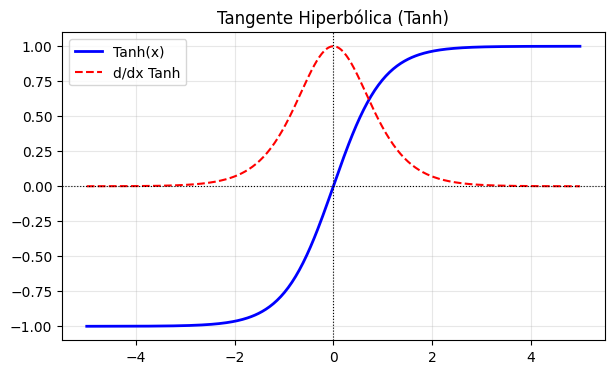

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

# Graficación
x = np.linspace(-5, 5, 400)
plt.figure(figsize=(7, 4))
plt.plot(x, tanh(x), label='Tanh(x)', color='blue', linewidth=2)
plt.plot(x, d_tanh(x), label='d/dx Tanh', color='red', linestyle='--')
plt.title('Tangente Hiperbólica (Tanh)')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2. Leaky ReLU

### Cómo funciona
Modifica la función ReLU tradicional permitiendo una pequeña pendiente constante $\alpha$ (habitualmente $0.01$) cuando $x < 0$. Esto asegura que las neuronas con valores negativos sigan transmitiendo gradientes durante el backpropagation.

* **Fórmula:** $f(x) = \max(\alpha x, x)$
* **Uso:** Capas ocultas donde se busca prevenir el problema del "Dying ReLU".

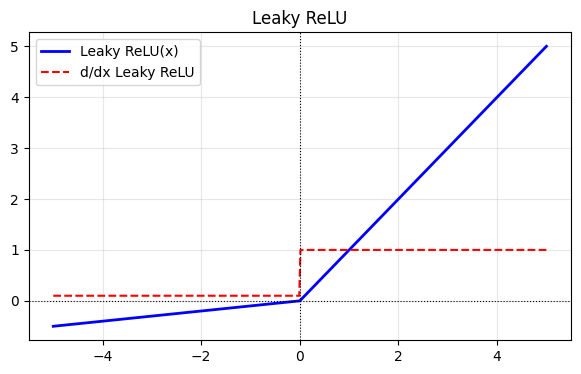

In [2]:
def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def d_leaky_relu(x, alpha=0.1):
    return np.where(x > 0, 1.0, alpha)

# Graficación
plt.figure(figsize=(7, 4))
plt.plot(x, leaky_relu(x), label='Leaky ReLU(x)', color='blue', linewidth=2)
plt.plot(x, d_leaky_relu(x), label='d/dx Leaky ReLU', color='red', linestyle='--')
plt.title('Leaky ReLU')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. GELU (Gaussian Error Linear Unit)

### Cómo funciona
Pesa las entradas multiplicándolas por la probabilidad de que una variable aleatoria normal caiga por debajo de $x$. Produce una curva suave que permite pequeñas activaciones negativas para entradas cercanas a cero.

* **Fórmula:** $f(x) = x \cdot \Phi(x)$ (donde $\Phi(x)$ es la distribución acumulada de la normal estándar).
* **Uso:** Estándar en arquitecturas Transformer (BERT, GPT, ViT).

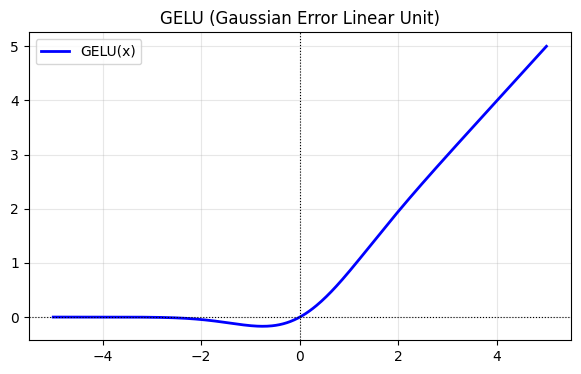

In [3]:
def gelu(x):
    # Aproximación común de GELU
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * np.power(x, 3))))

# Graficación
plt.figure(figsize=(7, 4))
plt.plot(x, gelu(x), label='GELU(x)', color='blue', linewidth=2)
plt.title('GELU (Gaussian Error Linear Unit)')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. SiLU / Swish (Sigmoid Linear Unit)

### Cómo funciona
Multiplica la entrada $x$ por la función sigmoide de $x$. Es suave, no monótona, y permite que pasen pequeños valores negativos antes de caer a cero, lo cual mejora el rendimiento en redes profundas.

* **Fórmula:** $f(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$
* **Uso:** Redes convolucionales modernas (YOLOv5/v8, EfficientNet) y LLMs (LLaMA).

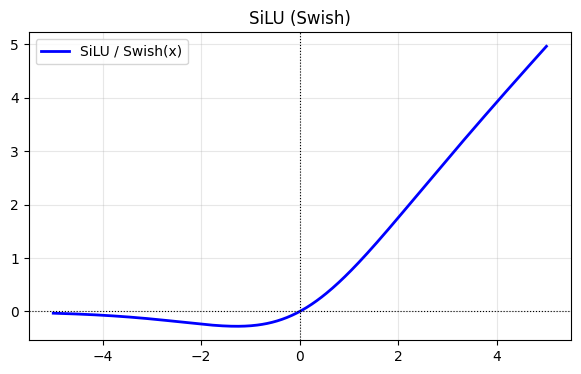

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def silu(x):
    return x * sigmoid(x)

# Graficación
plt.figure(figsize=(7, 4))
plt.plot(x, silu(x), label='SiLU / Swish(x)', color='blue', linewidth=2)
plt.title('SiLU (Swish)')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. SwiGLU (Swish-Gated Linear Unit)

### Cómo funciona
Aplica la función Swish sobre una transformación lineal y la multiplica elemento a elemento (*Hadamard product*) por otra transformación lineal independiente. Introduce un mecanismo de filtrado (gating) de alta capacidad.

* **Fórmula:** $\text{SwiGLU}(x) = \text{Swish}(xW + b) \otimes (xV + c)$
* **Uso:** Bloque Feed-Forward Network (FFN) en LLMs de última generación (LLaMA, Mistral, PaLM).

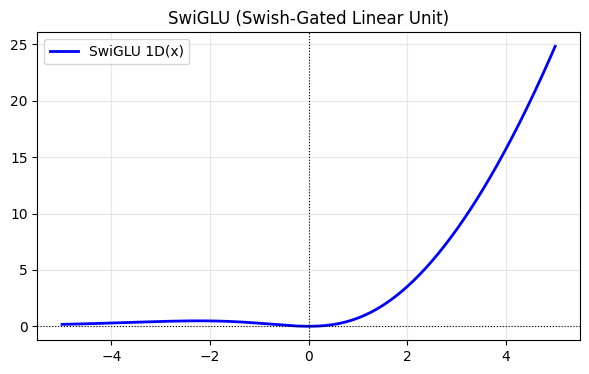

In [5]:
def swiglu_1d(x, w1=1.0, w2=1.0):
    # Demostración unidimensional simplificada
    return silu(x * w1) * (x * w2)

# Graficación
plt.figure(figsize=(7, 4))
plt.plot(x, swiglu_1d(x), label='SwiGLU 1D(x)', color='blue', linewidth=2)
plt.title('SwiGLU (Swish-Gated Linear Unit)')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Hard-Swish

### Cómo funciona
Reemplaza la función sigmoide costosa por una aproximación lineal por tramos basada en $\text{ReLU6}$. Acelera el cómputo significativamente en hardware de bajo consumo sin perder mucha precisión.

* **Fórmula:** $f(x) = x \cdot \frac{\text{ReLU6}(x + 3)}{6}$
* **Uso:** Dispositivos móviles, embebidos y Edge AI (MobileNetV3).

In [ ]:
def hard_swish(x):
    return x * (np.clip(x + 3, 0, 6) / 6)

# Graficación
plt.figure(figsize=(7, 4))
plt.plot(x, hard_swish(x), label='Hard-Swish(x)', color='blue', linewidth=2)
plt.title('Hard-Swish')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()